<a href="https://colab.research.google.com/github/Sam-Arkle/CS5455/blob/main/ProbabilityDistributionBernoulli.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

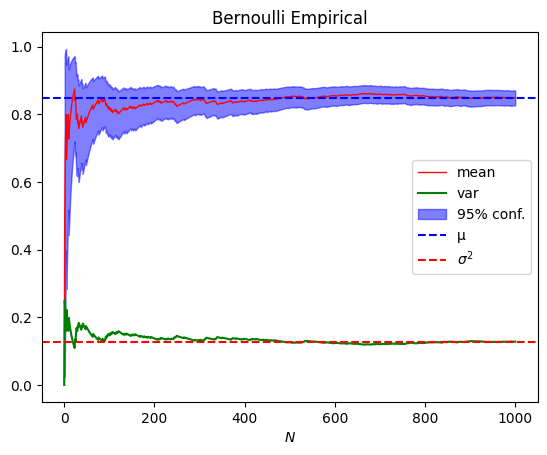

In [107]:
# Generating a bernoulli distribution and verifying the calculations for the mean and variance
import numpy as np
from scipy.stats import beta
from scipy.stats import bernoulli
import matplotlib.pyplot as plt

μ = 0.85 # Probability of heads
n = 1 # Number of coin flips
total_flips = 1000
a = 1 # Number heads + 1
b = 1 # Number tails + 1
confidence = .95

coins = []
sample_estimate_mean = []
sample_variance = []
confidence_lower = []
confidence_upper = []

# Flipping the coin total_flips times.
while n <= total_flips:
  # coins = np.random.binomial(1,μ,n) # Note, this formula for coins re-ran the entire experiment each time
  coins.append(bernoulli.rvs(μ))
  a = np.sum(coins)
  b = n - a
  mean = a / n # Mean for Bernoulli distribution
  sample_estimate_mean.append(mean)
  sample_variance.append((mean)*(1-(mean))) # Variance for Bernoulli distribution
  # sample_estimate_mean.append(beta.stats(a,b,moments='m'))
  # sample_variance.append(beta.stats(a,b,moments='v'))

  #Getting the confidence intervals
  lower , upper = beta.interval(confidence, a, b)
  confidence_lower.append(lower)
  confidence_upper.append(upper)
  n+=1


# Plotting out the data
x = np.linspace(0,total_flips,total_flips)
plt.plot(x, sample_estimate_mean, color='red',alpha=0.95,label='mean', linewidth=1)
plt.plot(x, sample_variance, color='green',label='var')
plt.fill_between(x,confidence_lower, confidence_upper, color='blue', alpha=.5, label='95% conf.')
plt.axhline(μ, color='blue', linestyle='dashed', label='μ')
variance = bernoulli.stats(μ, moments='v') # variance for bernoulli distribution given μ
plt.axhline(variance, color='red', linestyle='dashed', label='$σ^2$')
plt.xlabel('$N$')
plt.title('Bernoulli Empirical')
plt.legend()
plt.show()

$\frac{a \times b}{(a+b)^2\times(a+b+1)} $
$\sigma^2$